In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

In [3]:
data = pd.read_csv('../M1_final.csv')
data.head()

,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,TAIL_NUM,DEST,DEP_DELAY,CRS_ELAPSED_TIME,DISTANCE,CRS_DEP_M,...,Dew Point,Humidity,Wind,Wind Speed,Wind Gust,Pressure,Condition,sch_dep,sch_arr,TAXI_OUT
0,11,1,5,B6,N828JB,CHS,-1,124,636,324,...,34,58,W,25,38,29.86,Fair / Windy,9,17,14
1,11,1,5,B6,N992JB,LAX,-7,371,2475,340,...,34,58,W,25,38,29.86,Fair / Windy,9,17,15
2,11,1,5,B6,N959JB,FLL,40,181,1069,301,...,34,58,W,25,38,29.86,Fair / Windy,9,17,22
3,11,1,5,B6,N999JQ,MCO,-2,168,944,345,...,34,58,W,25,38,29.86,Fair / Windy,9,17,12
4,11,1,5,DL,N880DN,ATL,-4,139,760,360,...,32,58,W,24,35,29.91,Fair / Windy,9,17,13


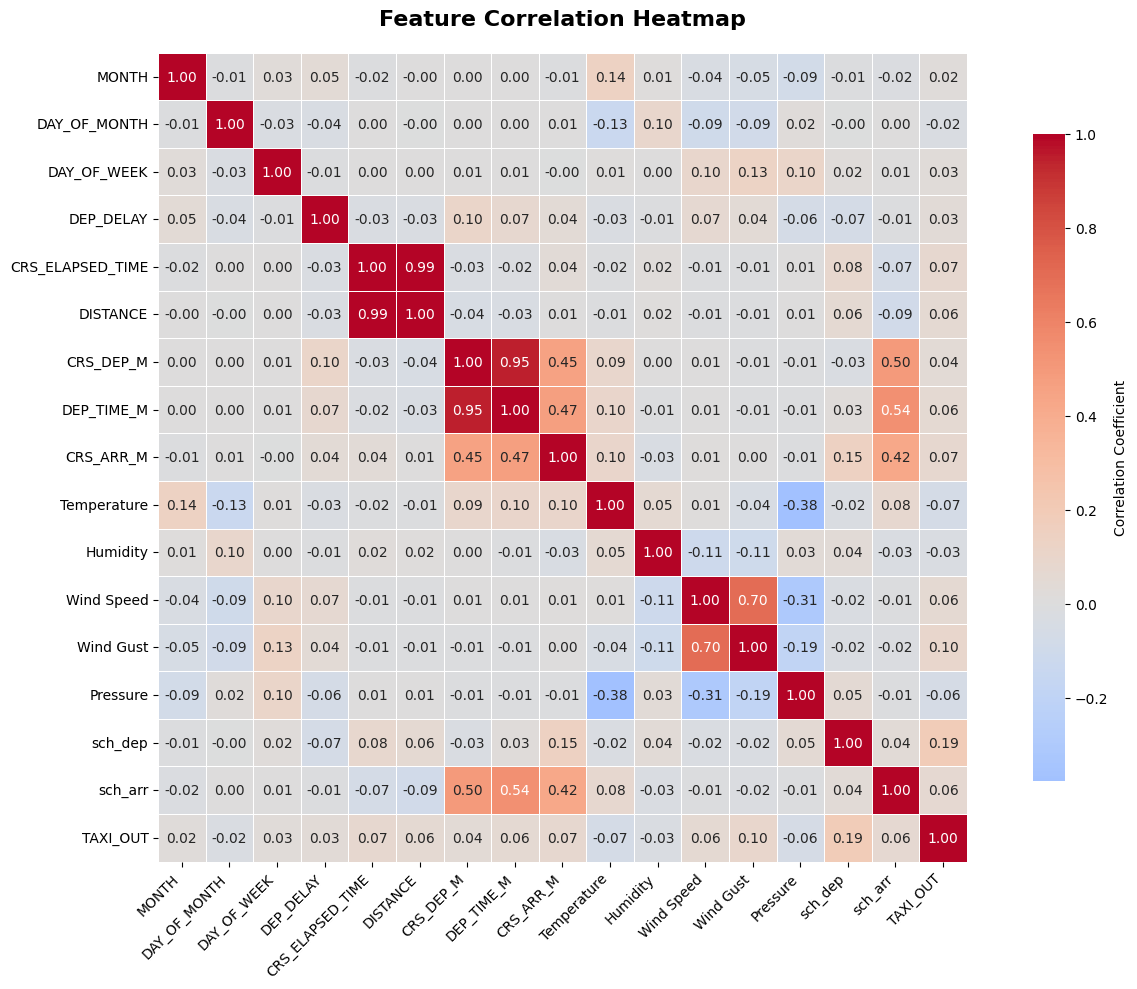

In [4]:
import seaborn as sns

# Calculate correlation matrix
corr_matrix = data.corr(numeric_only=True)

# Create enhanced heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,           # Show correlation values
    fmt='.2f',            # Format to 2 decimal places
    cmap='coolwarm',      # Color scheme (blue for negative, red for positive)
    center=0,             # Center colormap at 0
    square=True,          # Make cells square-shaped
    linewidths=0.5,       # Add gridlines between cells
    cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'}
)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [5]:

# create target variable
data['is_delayed'] = np.where(
    data['DEP_DELAY'] >= 15,
    1,
    0
)
data.drop(columns=['DEP_DELAY'], inplace=True)

In [6]:
# Function to create temporal features
def create_temporal_features(df):

    df = df.copy()
    
    # Create a new date_order column to sort data according to date time
    df['date_order'] = df['MONTH'] * 100 + df['DAY_OF_MONTH']
    
    # Sort by destination, date, then departure time
    df = df.sort_values(["DEST", "date_order", "CRS_DEP_M"])
    
    # Previous flight delay at same destination
    df["prev_delay"] = df.groupby("DEST")["is_delayed"].shift(1)
    
    # Rolling delay rate over last 3 flights at same destination
    df["rolling_delay_rate_3"] = (
        df.groupby("DEST")["is_delayed"]
        .rolling(3, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )
    
    # Rolling delay rate over last 5 flights at same destination
    df["rolling_delay_rate_5"] = (
        df.groupby("DEST")["is_delayed"]
        .rolling(5, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )
    
    # Fill NaN values from the shift operation
    df["prev_delay"] = df["prev_delay"].fillna(0)
    
    # Drop temporary date_order column
    df = df.drop('date_order', axis=1)
    
    return df

In [7]:
# Stratified Train test split
from sklearn.model_selection import StratifiedShuffleSplit

x = data.drop('is_delayed', axis=1)
y = data['is_delayed']

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)

for train_index, test_index in splitter.split(data, data['is_delayed']):
    # Split the data first
    train_data = data.iloc[train_index].copy()
    test_data = data.iloc[test_index].copy()
    
    # Apply temporal features separately to avoid leakage
    train_data = create_temporal_features(train_data)
    test_data = create_temporal_features(test_data)
    
    # Now split into X and y
    x_train = train_data.drop('is_delayed', axis=1)
    y_train = train_data['is_delayed']
    x_test = test_data.drop('is_delayed', axis=1)
    y_test = test_data['is_delayed']

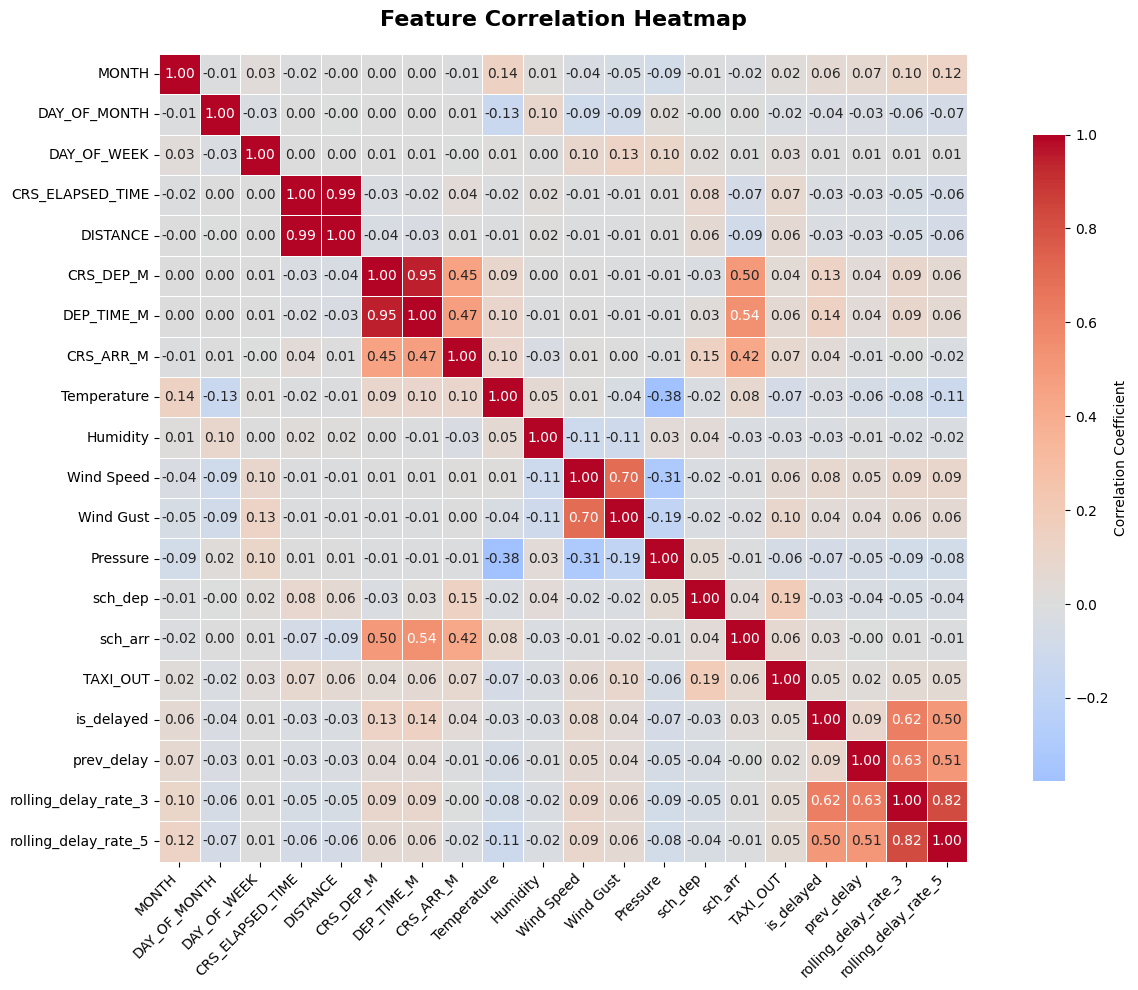

In [8]:
import seaborn as sns

# Calculate correlation matrix
data = create_temporal_features(data)

corr_matrix = data.corr(numeric_only=True)

# Create enhanced heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,           # Show correlation values
    fmt='.2f',            # Format to 2 decimal places
    cmap='coolwarm',      # Color scheme (blue for negative, red for positive)
    center=0,             # Center colormap at 0
    square=True,          # Make cells square-shaped
    linewidths=0.5,       # Add gridlines between cells
    cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'}
)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
def get_time_of_day(minutes):
    if 300 <= minutes < 720:        # 5:00am - 11:59am
        return 'Morning'
    elif 720 <= minutes < 1020:     # 12:00pm - 4:59pm
        return 'Afternoon'
    elif 1020 <= minutes < 1260:    # 5:00pm - 8:59pm
        return 'Evening'
    else:                           # 9:00pm - 4:59am
        return 'Night'
    

data['time_of_day'] = data['CRS_DEP_M'].apply(get_time_of_day)

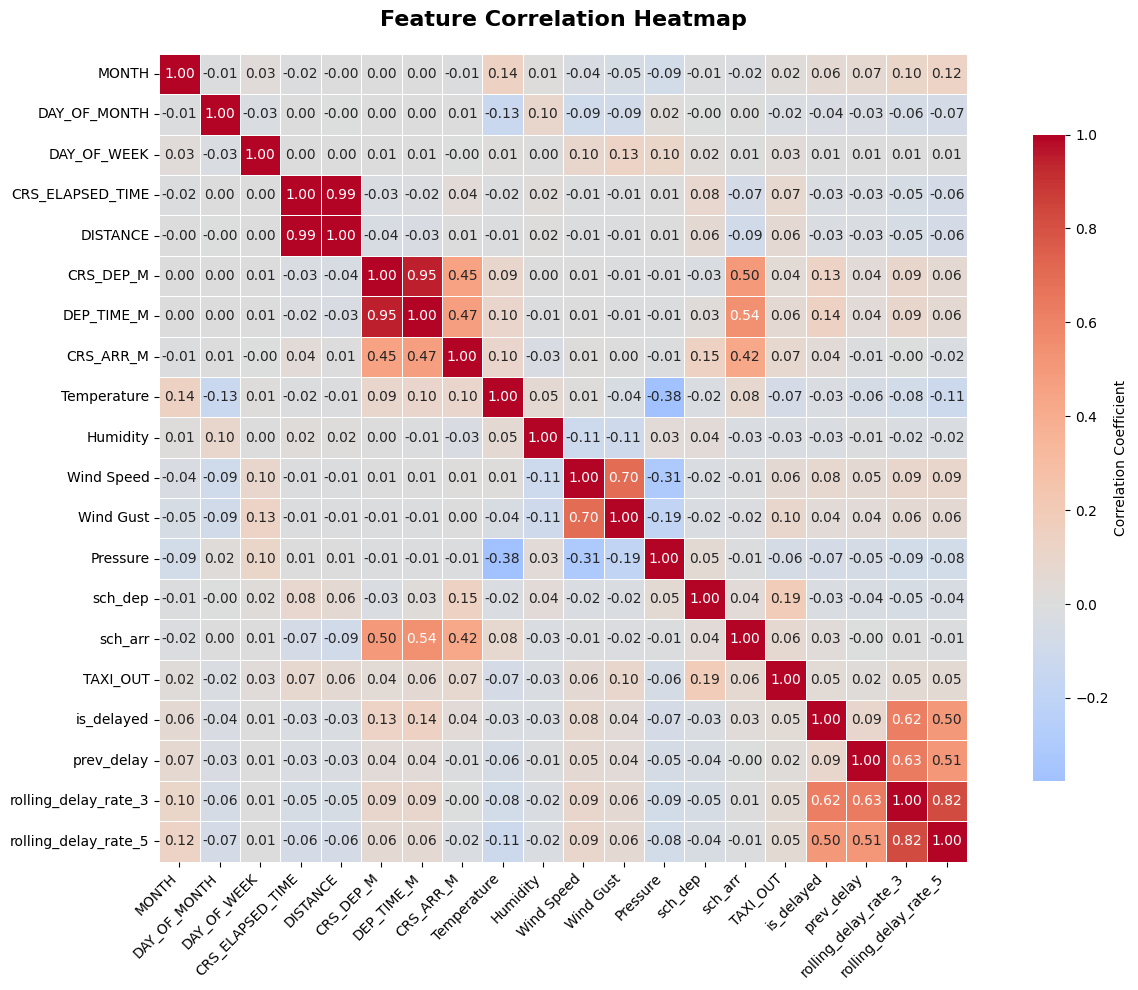

In [10]:
import seaborn as sns

# Calculate correlation matrix
corr_matrix = data.corr(numeric_only=True)

# Create enhanced heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,           # Show correlation values
    fmt='.2f',            # Format to 2 decimal places
    cmap='coolwarm',      # Color scheme (blue for negative, red for positive)
    center=0,             # Center colormap at 0
    square=True,          # Make cells square-shaped
    linewidths=0.5,       # Add gridlines between cells
    cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'}
)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Analyzing Time of Day vs Delay Correlation

We'll explore the relationship between time_of_day and is_delayed using multiple methods:

In [11]:
# Method 1: Crosstab to see delay rates by time of day
delay_by_time = pd.crosstab(
    data['time_of_day'], 
    data['is_delayed'], 
    normalize='index'
) * 100

print("Delay Rate (%) by Time of Day:")
print(delay_by_time)
print("\n" + "="*50 + "\n")

# Calculate actual delay rate for each time period
delay_rate = data.groupby('time_of_day')['is_delayed'].agg(['mean', 'count'])
delay_rate['delay_rate_%'] = delay_rate['mean'] * 100
delay_rate = delay_rate.sort_values('delay_rate_%', ascending=False)

print("Detailed Delay Statistics by Time of Day:")
print(delay_rate)

Delay Rate (%) by Time of Day:
is_delayed           0          1
time_of_day                      
Afternoon    84.586050  15.413950
Evening      81.271424  18.728576
Morning      90.926036   9.073964
Night        79.959514  20.040486


Detailed Delay Statistics by Time of Day:
                 mean  count  delay_rate_%
time_of_day                               
Night        0.200405   2470     20.040486
Evening      0.187286   6418     18.728576
Afternoon    0.154140   8129     15.413950
Morning      0.090740  11803      9.073964


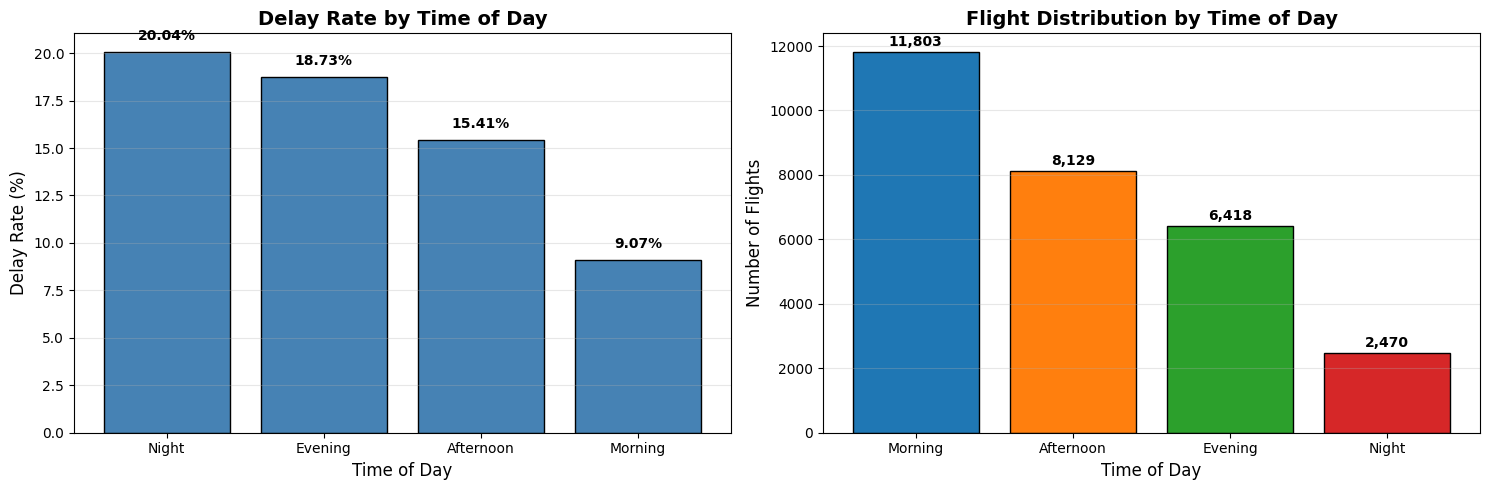

In [12]:
# Method 2: Visualize the relationship
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot of delay rates
delay_rate_plot = data.groupby('time_of_day')['is_delayed'].mean() * 100
delay_rate_plot = delay_rate_plot.sort_values(ascending=False)

axes[0].bar(delay_rate_plot.index, delay_rate_plot.values, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Time of Day', fontsize=12)
axes[0].set_ylabel('Delay Rate (%)', fontsize=12)
axes[0].set_title('Delay Rate by Time of Day', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (idx, val) in enumerate(delay_rate_plot.items()):
    axes[0].text(i, val + 0.5, f'{val:.2f}%', ha='center', va='bottom', fontweight='bold')

# Count plot
time_counts = data['time_of_day'].value_counts()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
axes[1].bar(time_counts.index, time_counts.values, color=colors, edgecolor='black')
axes[1].set_xlabel('Time of Day', fontsize=12)
axes[1].set_ylabel('Number of Flights', fontsize=12)
axes[1].set_title('Flight Distribution by Time of Day', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (idx, val) in enumerate(time_counts.items()):
    axes[1].text(i, val + 100, f'{val:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28820 entries, 19202 to 18941
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   MONTH                 28820 non-null  int64  
 1   DAY_OF_MONTH          28820 non-null  int64  
 2   DAY_OF_WEEK           28820 non-null  int64  
 3   OP_UNIQUE_CARRIER     28820 non-null  object 
 4   TAIL_NUM              28820 non-null  object 
 5   DEST                  28820 non-null  object 
 6   CRS_ELAPSED_TIME      28820 non-null  int64  
 7   DISTANCE              28820 non-null  int64  
 8   CRS_DEP_M             28820 non-null  int64  
 9   DEP_TIME_M            28820 non-null  int64  
 10  CRS_ARR_M             28820 non-null  int64  
 11  Temperature           28820 non-null  int64  
 12  Dew Point             28820 non-null  object 
 13  Humidity              28820 non-null  int64  
 14  Wind                  28818 non-null  object 
 15  Wind Speed          

In [14]:
data['Condition'].unique()

array(['Partly Cloudy', 'Mostly Cloudy', 'Light Rain', 'Cloudy', 'Fair',
       'Cloudy / Windy', 'Fair / Windy', 'Light Snow', 'Rain',
       'Mostly Cloudy / Windy', 'Wintry Mix', 'Light Drizzle', 'Fog',
       'Partly Cloudy / Windy', 'Fog / Windy', 'Light Rain / Windy',
       'Rain / Windy', 'Wintry Mix / Windy', 'Heavy Rain',
       'Light Snow / Windy', 'Heavy Rain / Windy', 'Drizzle and Fog',
       'Light Drizzle / Windy', 'Light Freezing Rain', 'Snow'],
      dtype=object)

## Feature Engineering: Weather-Delay Interaction Features

Creating derived features based on available columns:
- **rain_intensity**: Extracted from `Condition` column
- **wind_delay_interaction**: Using `Wind Speed` × rolling delay metrics
- **rain_delay_ratio**: Using rain intensity / rolling delay metrics

In [ ]:
# Function to extract rain intensity from weather condition
def extract_rain_intensity(condition):
    """
    Extract rain intensity from weather condition string
    Returns: 0 (No rain), 1 (Light), 2 (Moderate), 3 (Heavy)
    """
    condition = str(condition).lower()
    
    if 'heavy rain' in condition:
        return 3
    elif 'rain' in condition and 'light' not in condition:
        return 2  # Regular rain
    elif 'light rain' in condition or 'light drizzle' in condition or 'drizzle' in condition:
        return 1
    elif 'light freezing rain' in condition:
        return 1
    else:
        return 0  # No rain


# Function to create weather interaction features
def create_weather_interaction_features(df):
    """
    Create weather-delay interaction features.
    Must be called AFTER create_temporal_features() to ensure rolling_delay_rate_3 exists.
    
    Features created:
    - rain_intensity: Extracted from Condition column (0-3 scale)
    - wind_delay_interaction: Wind Speed × rolling_delay_rate_3
    - rain_delay_ratio: (rain_intensity + 1) / (rolling_delay_rate_3 + 1)
    
    Args:
        df: DataFrame with 'Condition', 'Wind Speed', and 'rolling_delay_rate_3' columns
    
    Returns:
        DataFrame with added weather interaction features
    """
    df = df.copy()
    
    # Create rain_intensity feature
    df['rain_intensity'] = df['Condition'].apply(extract_rain_intensity)
    
    # Create wind-delay interaction feature
    df['wind_delay_interaction'] = df['Wind Speed'] * df['rolling_delay_rate_3']
    
    # Create rain-delay ratio feature
    df['rain_delay_ratio'] = (df['rain_intensity'] + 1) / (df['rolling_delay_rate_3'] + 1)
    
    return df

✓ Rain intensity feature created!

Rain Intensity Distribution:
rain_intensity
0    26010
1     2374
2      376
3       60
Name: count, dtype: int64

Sample mappings:
                   Condition  rain_intensity
19202          Partly Cloudy               0
19522          Mostly Cloudy               0
21756                 Cloudy               0
22693                   Fair               0
9136            Fair / Windy               0
5517          Cloudy / Windy               0
10141             Light Snow               0
13714  Mostly Cloudy / Windy               0
22422            Fog / Windy               0
14340             Wintry Mix               0
20227  Partly Cloudy / Windy               0
19924                    Fog               0
14906     Light Snow / Windy               0
24503                   Snow               0
10129     Wintry Mix / Windy               0


In [ ]:
# Test the function on the full dataset
data_with_features = create_weather_interaction_features(data)

print("✓ Weather interaction features created!")
print(f"\nNew features added:")
print(f"  1. rain_intensity (0-3 scale)")
print(f"  2. wind_delay_interaction")
print(f"  3. rain_delay_ratio")
print(f"\nTotal columns now: {len(data_with_features.columns)}")

# Show feature statistics
print("\n" + "="*70)
print("FEATURE STATISTICS")
print("="*70)
print("\nRain Intensity Distribution:")
print(data_with_features['rain_intensity'].value_counts().sort_index())
print(f"\nWind-Delay Interaction - Range: [{data_with_features['wind_delay_interaction'].min():.2f}, {data_with_features['wind_delay_interaction'].max():.2f}]")
print(f"Rain-Delay Ratio - Range: [{data_with_features['rain_delay_ratio'].min():.2f}, {data_with_features['rain_delay_ratio'].max():.2f}]")

In [16]:
# Step 2: Create interaction features using actual column names

# Feature 1: wind_delay_interaction
# Using 'Wind Speed' (actual column name) and 'rolling_delay_rate_3' (better correlation than rolling_5)
data["wind_delay_interaction"] = data["Wind Speed"] * data["rolling_delay_rate_3"]

# Feature 2: rain_delay_ratio  
# Using newly created 'rain_intensity' and 'rolling_delay_rate_3'
data["rain_delay_ratio"] = (data["rain_intensity"] + 1) / (data["rolling_delay_rate_3"] + 1)

print("✓ Interaction features created successfully!")
print("\n" + "="*70)
print("Feature Mapping:")
print("  • wind_speed → 'Wind Speed' column")
print("  • avg_delay_last_hour → 'rolling_delay_rate_3' (better correlation)")
print("  • rain_intensity → Derived from 'Condition' column")
print("="*70)
print(f"\nNew features added:")
print(f"  1. rain_intensity (0-3 scale)")
print(f"  2. wind_delay_interaction")
print(f"  3. rain_delay_ratio")
print(f"\nTotal columns now: {len(data.columns)}")

✓ Interaction features created successfully!

Feature Mapping:
  • wind_speed → 'Wind Speed' column
  • avg_delay_last_hour → 'rolling_delay_rate_3' (better correlation)
  • rain_intensity → Derived from 'Condition' column

New features added:
  1. rain_intensity (0-3 scale)
  2. wind_delay_interaction
  3. rain_delay_ratio

Total columns now: 30


In [17]:
# Step 3: Verify the new features and check statistics
print("="*70)
print("FEATURE STATISTICS")
print("="*70)

print("\n1. Rain Intensity (0=None, 1=Light, 2=Moderate, 3=Heavy):")
print(data["rain_intensity"].describe())

print("\n2. Wind-Delay Interaction:")
print(data["wind_delay_interaction"].describe())

print("\n3. Rain-Delay Ratio:")
print(data["rain_delay_ratio"].describe())

# Check for any data quality issues
print("\n" + "="*70)
print("DATA QUALITY CHECK")
print("="*70)
for col in ['rain_intensity', 'wind_delay_interaction', 'rain_delay_ratio']:
    nan_count = data[col].isna().sum()
    inf_count = np.isinf(data[col]).sum()
    print(f"  {col}:")
    print(f"    - NaN values: {nan_count}")
    print(f"    - Inf values: {inf_count}")
    
print("\n✓ All features created successfully!")

FEATURE STATISTICS

1. Rain Intensity (0=None, 1=Light, 2=Moderate, 3=Heavy):
count    28820.000000
mean         0.114712
std          0.374356
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          3.000000
Name: rain_intensity, dtype: float64

2. Wind-Delay Interaction:
count    28820.000000
mean         1.849746
std          3.392242
min          0.000000
25%          0.000000
50%          0.000000
75%          3.000000
max         31.000000
Name: wind_delay_interaction, dtype: float64

3. Rain-Delay Ratio:
count    28820.000000
mean         1.004762
std          0.359767
min          0.500000
25%          0.750000
50%          1.000000
75%          1.000000
max          4.000000
Name: rain_delay_ratio, dtype: float64

DATA QUALITY CHECK
  rain_intensity:
    - NaN values: 0
    - Inf values: 0
  wind_delay_interaction:
    - NaN values: 0
    - Inf values: 0
  rain_delay_ratio:
    - NaN values: 0
    - Inf values: 0

✓ All features cre

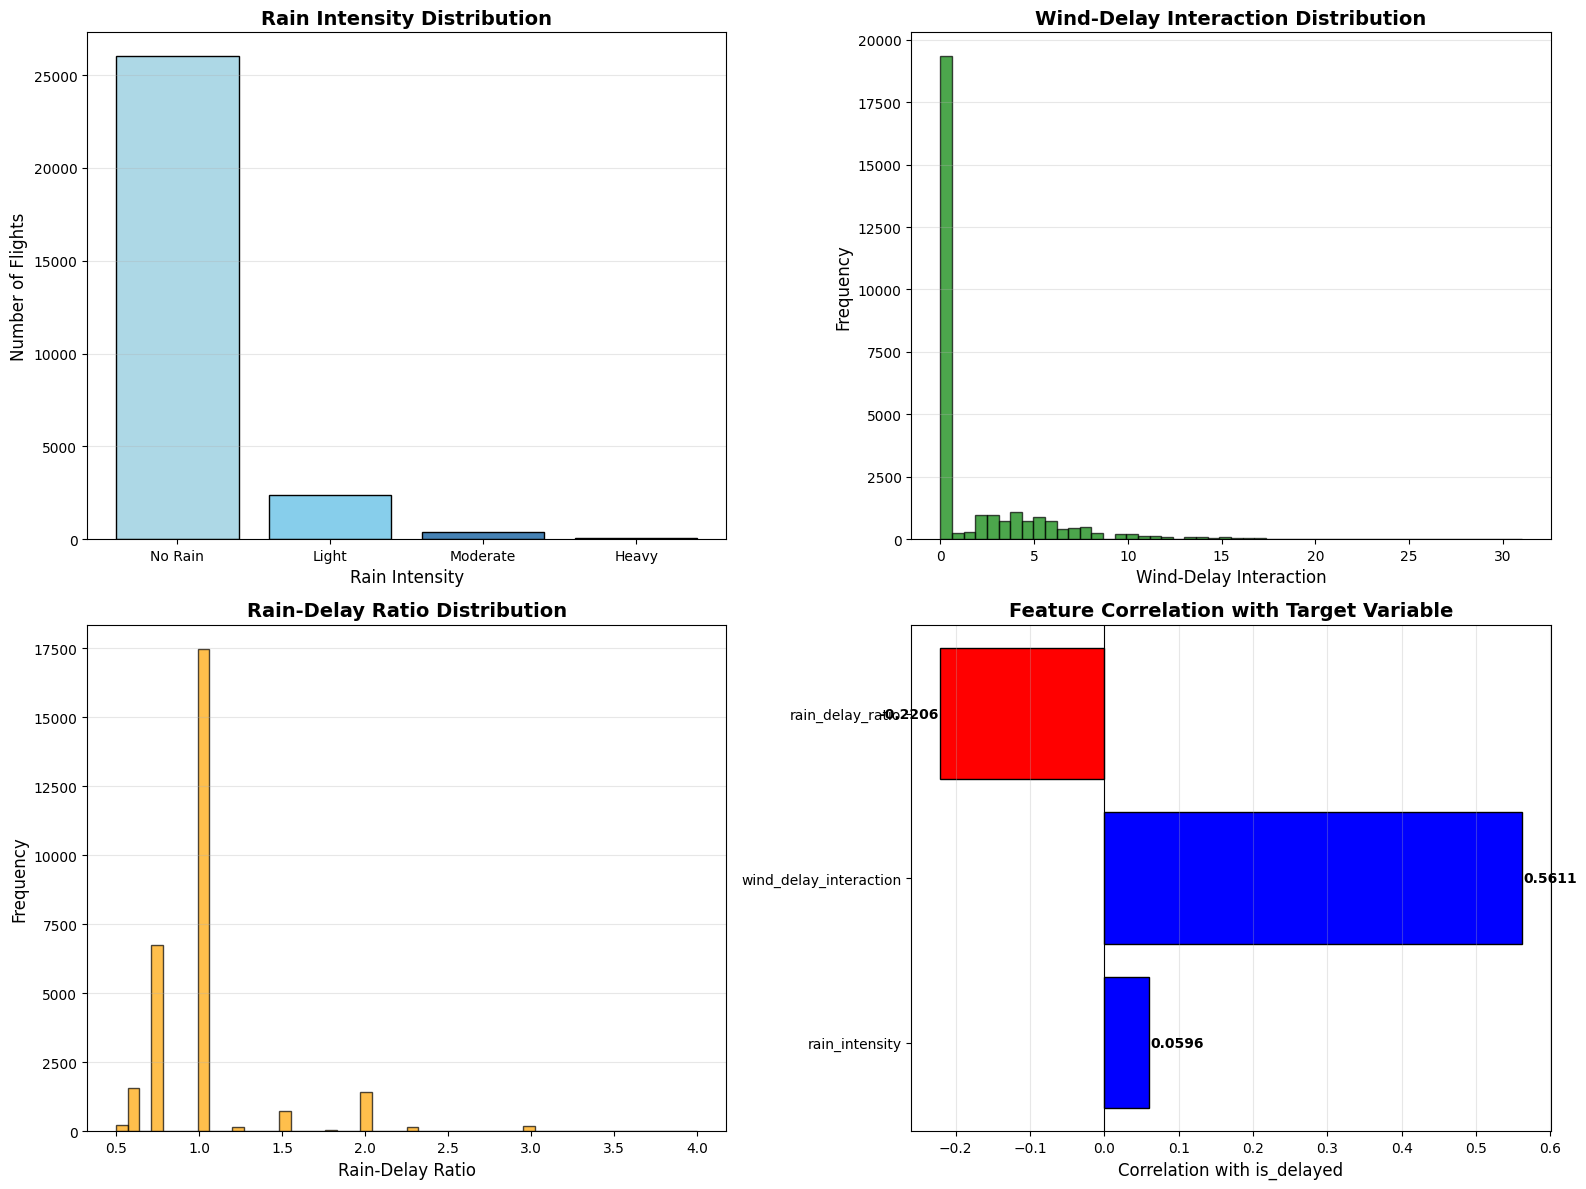


Correlation with Target Variable (is_delayed):
  rain_intensity: 0.0596
  wind_delay_interaction: 0.5611
  rain_delay_ratio: -0.2206


In [18]:
# Step 4: Visualize the new features
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Rain Intensity Distribution
rain_counts = data['rain_intensity'].value_counts().sort_index()
rain_labels = ['No Rain', 'Light', 'Moderate', 'Heavy']
axes[0, 0].bar(rain_counts.index, rain_counts.values, color=['lightblue', 'skyblue', 'steelblue', 'darkblue'], edgecolor='black')
axes[0, 0].set_xlabel('Rain Intensity', fontsize=12)
axes[0, 0].set_ylabel('Number of Flights', fontsize=12)
axes[0, 0].set_title('Rain Intensity Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(range(4))
axes[0, 0].set_xticklabels(rain_labels)
axes[0, 0].grid(axis='y', alpha=0.3)

# Plot 2: Wind-Delay Interaction Distribution
axes[0, 1].hist(data['wind_delay_interaction'], bins=50, color='green', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Wind-Delay Interaction', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('Wind-Delay Interaction Distribution', fontsize=14, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# Plot 3: Rain-Delay Ratio Distribution
axes[1, 0].hist(data['rain_delay_ratio'], bins=50, color='orange', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Rain-Delay Ratio', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('Rain-Delay Ratio Distribution', fontsize=14, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Correlation with is_delayed
new_features = ['rain_intensity', 'wind_delay_interaction', 'rain_delay_ratio']
correlations = [data[feat].corr(data['is_delayed']) for feat in new_features]
colors_corr = ['blue' if c > 0 else 'red' for c in correlations]
axes[1, 1].barh(new_features, correlations, color=colors_corr, edgecolor='black')
axes[1, 1].set_xlabel('Correlation with is_delayed', fontsize=12)
axes[1, 1].set_title('Feature Correlation with Target Variable', fontsize=14, fontweight='bold')
axes[1, 1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
axes[1, 1].grid(axis='x', alpha=0.3)

# Add correlation values as text
for i, (feat, corr) in enumerate(zip(new_features, correlations)):
    axes[1, 1].text(corr + 0.002 if corr > 0 else corr - 0.002, i, f'{corr:.4f}', 
                    va='center', ha='left' if corr > 0 else 'right', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Correlation with Target Variable (is_delayed):")
print("="*70)
for feat, corr in zip(new_features, correlations):
    print(f"  {feat}: {corr:.4f}")

## Updated Correlation Heatmap

Visualizing correlations with all features including the newly engineered ones:

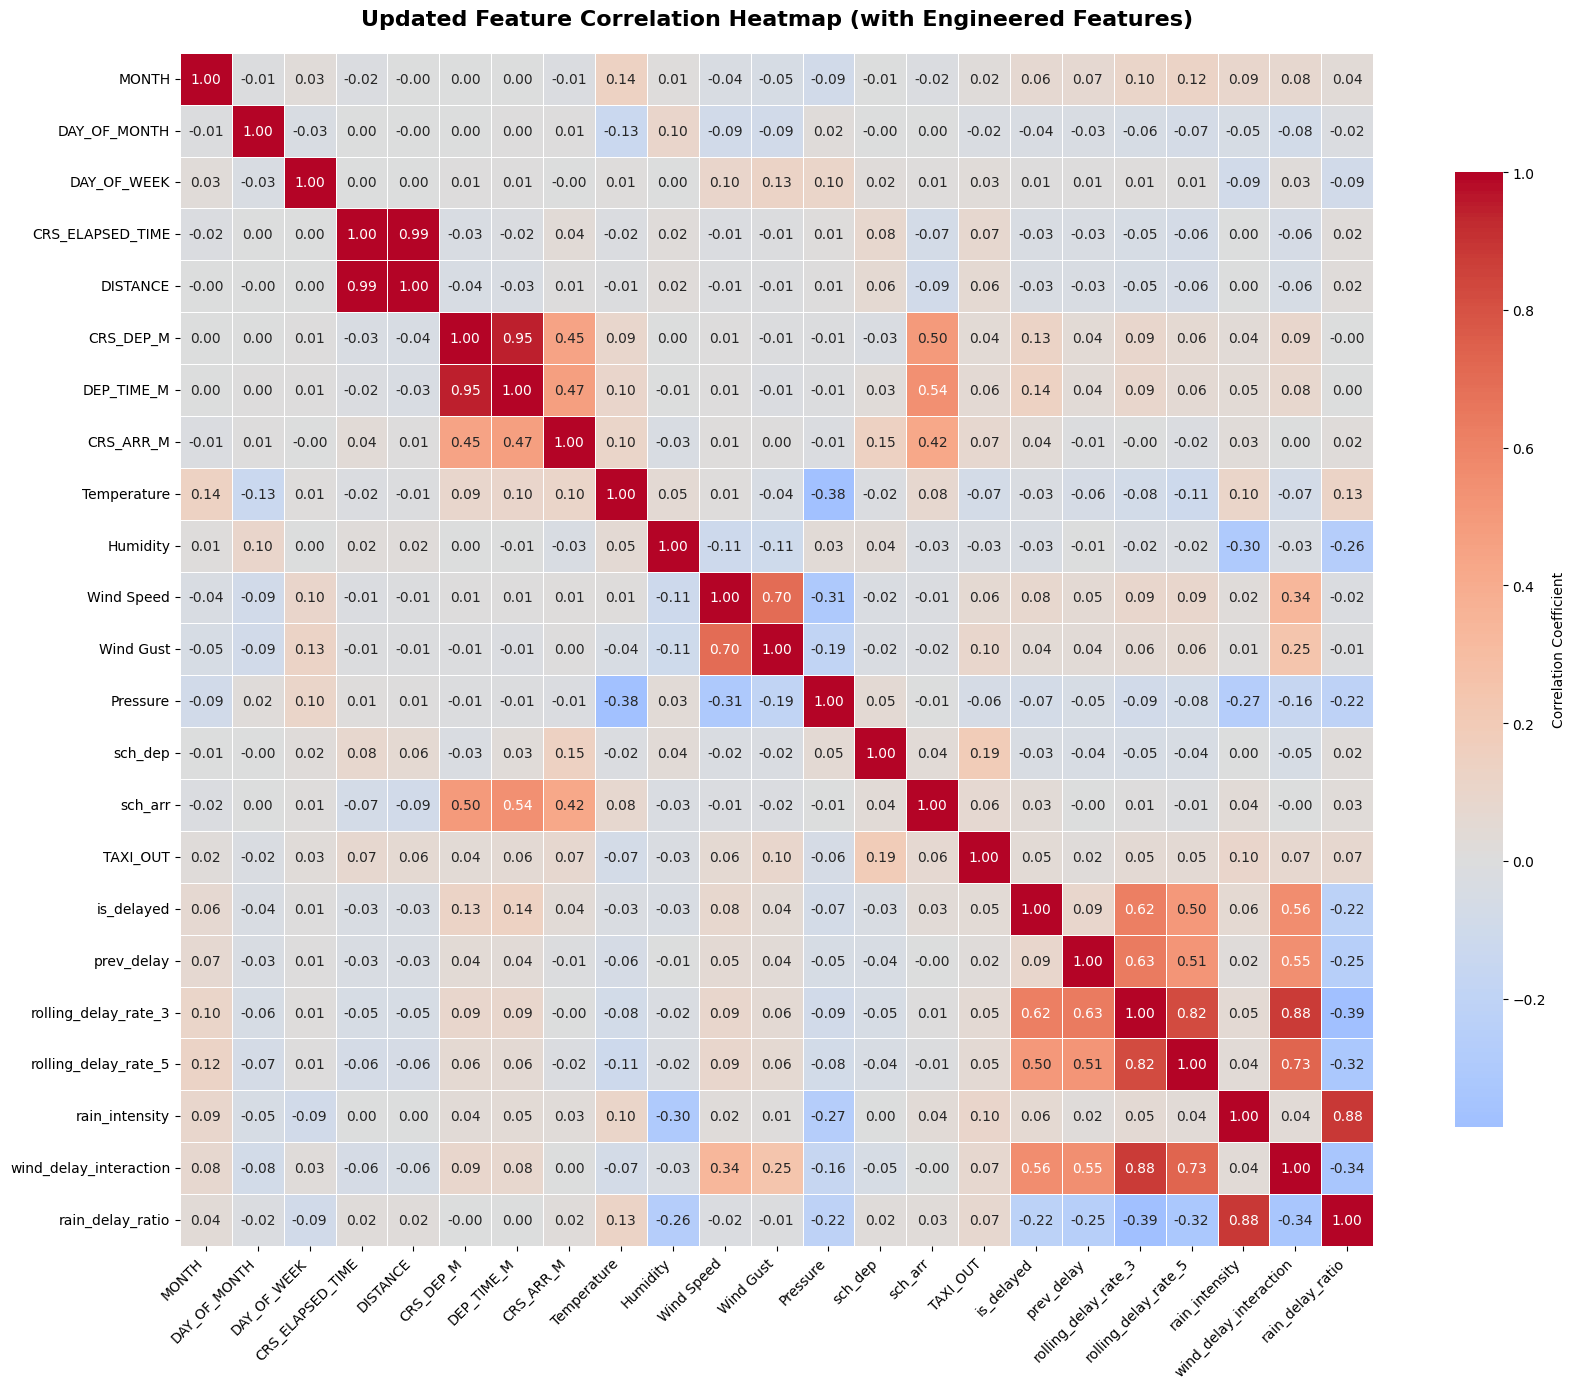


Total numeric features: 23
New engineered features: rain_intensity, wind_delay_interaction, rain_delay_ratio


In [19]:
# Calculate correlation matrix with all features (including new ones)
corr_matrix_updated = data.corr(numeric_only=True)

# Create enhanced heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_matrix_updated,
    annot=True,           # Show correlation values
    fmt='.2f',            # Format to 2 decimal places
    cmap='coolwarm',      # Color scheme (blue for negative, red for positive)
    center=0,             # Center colormap at 0
    square=True,          # Make cells square-shaped
    linewidths=0.5,       # Add gridlines between cells
    cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'}
)
plt.title('Updated Feature Correlation Heatmap (with Engineered Features)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Show the new features count
print(f"\nTotal numeric features: {len(corr_matrix_updated.columns)}")
print(f"New engineered features: rain_intensity, wind_delay_interaction, rain_delay_ratio")